In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

In [ ]:
data = pd.read_csv(PROJECT_ROOT / "data/raw/hvac_training_dataset.csv")
data.head()

,building_type,climate_zone,budget_level,area_sqft,floors,ceiling_height,occupancy,operating_hours,building_age,outdoor_temp,humidity,insulation,glass_ratio,recommended_hvac
0,Residential,NaN,Medium,1021.68,1.0,8.47,28.0,11.0,29.0,33.32,83.40,Good,Low,Central Chiller
1,Office,Hot,Low,500.00,1.0,10.19,42.0,11.0,13.0,48.24,43.94,Poor,High,VRF
2,Industrial,Humid,Low,90186.19,4.0,21.60,4494.0,14.0,12.0,32.08,88.89,Average,Low,VRF
3,Residential,NaN,Medium,2316.93,1.0,8.27,34.0,7.0,1.0,42.36,95.71,Good,Low,Split AC
4,Residential,Hot,Medium,705.85,1.0,8.04,16.0,8.0,9.0,34.64,36.91,Good,Low,Multi-Split


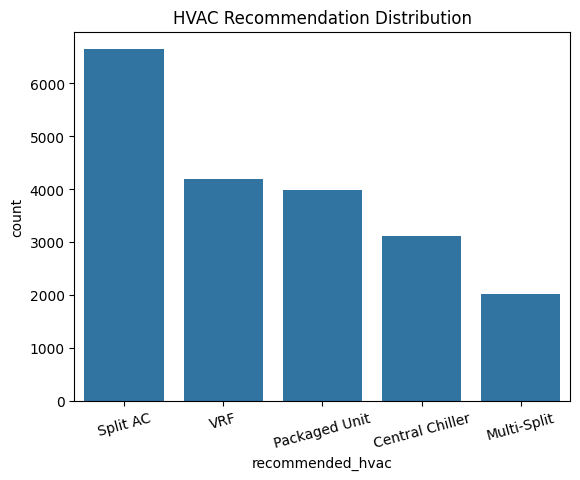

In [ ]:
sns.countplot(
    data=data,
    x="recommended_hvac",
    order=data["recommended_hvac"].value_counts().index
)

plt.title("HVAC Recommendation Distribution")
plt.xticks(rotation=15)
plt.show()

In [ ]:
model_df = data

In [ ]:
model_df.isna().sum()

building_type       404
climate_zone        413
budget_level        409
area_sqft           405
floors              434
ceiling_height      374
occupancy           383
operating_hours     396
building_age        380
outdoor_temp        386
humidity            395
insulation          396
glass_ratio         452
recommended_hvac      0
dtype: int64

In [ ]:
print(model_df["recommended_hvac"].value_counts(normalize=True) * 100)

recommended_hvac
Split AC           33.220
VRF                21.020
Packaged Unit      19.955
Central Chiller    15.640
Multi-Split        10.165
Name: proportion, dtype: float64


In [ ]:
missing = (
    model_df.isnull().mean().sort_values(ascending=False) * 100
)

print(missing)

glass_ratio         2.260
floors              2.170
climate_zone        2.065
budget_level        2.045
area_sqft           2.025
building_type       2.020
insulation          1.980
operating_hours     1.980
humidity            1.975
outdoor_temp        1.930
occupancy           1.915
building_age        1.900
ceiling_height      1.870
recommended_hvac    0.000
dtype: float64


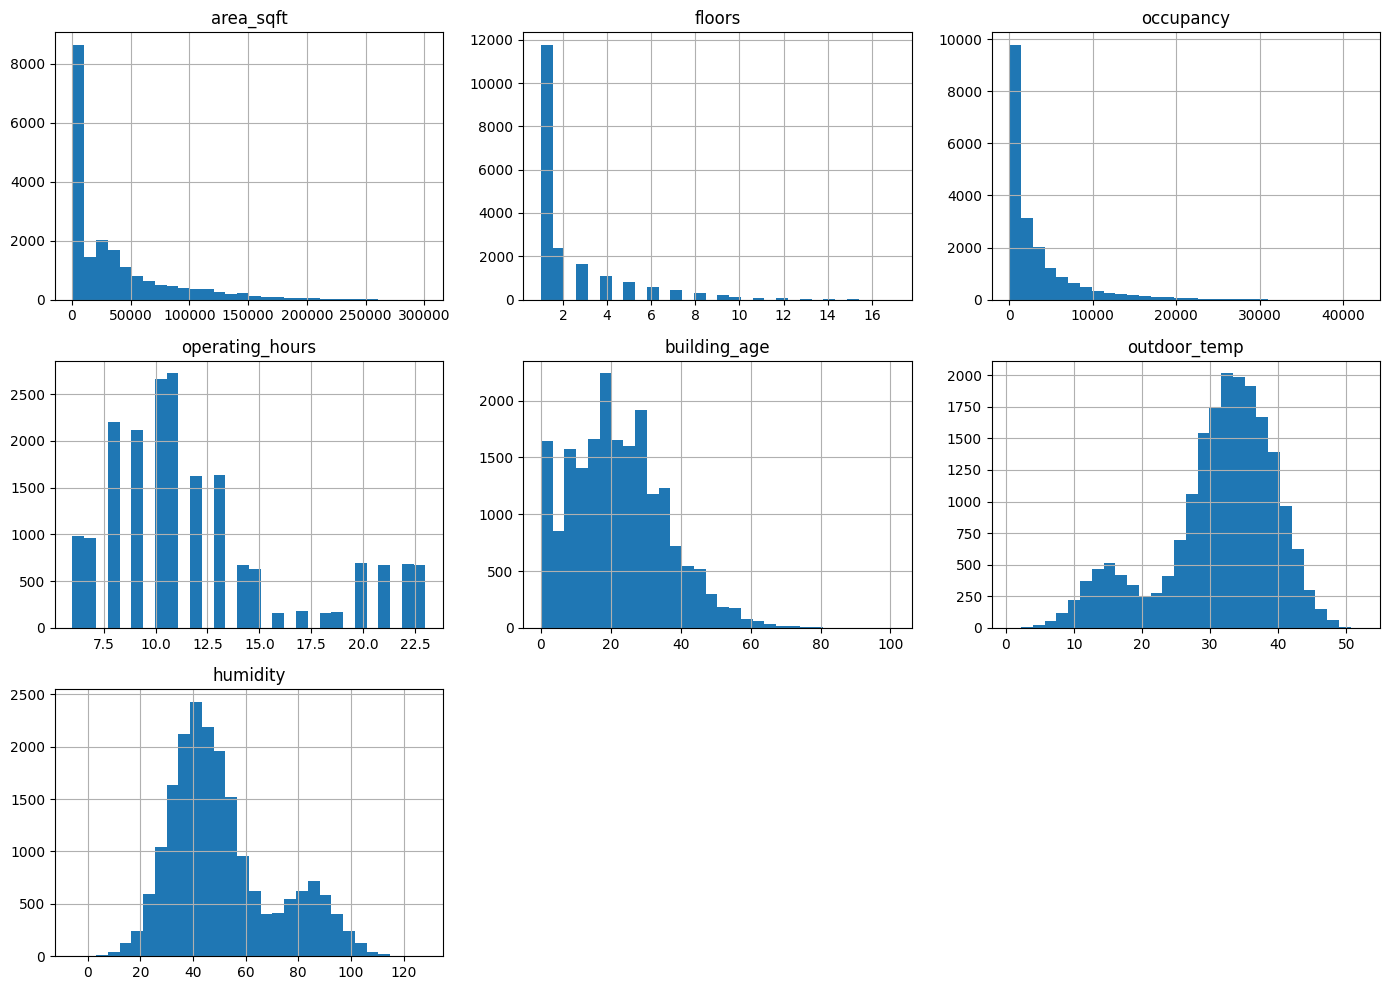

In [ ]:
numerical_cols = [
    "area_sqft",
    "floors",
    "occupancy",
    "operating_hours",
    "building_age",
    "outdoor_temp",
    "humidity"
]

model_df[numerical_cols].hist(
    figsize=(14,10),
    bins=30
)

plt.tight_layout()

plt.show()

In [ ]:
categorical_cols = [
    "building_type",
    "climate_zone",
    "budget_level",
    "insulation",
    "glass_ratio"
]

for col in categorical_cols:

    print("\n", col)

    print(model_df[col].value_counts(normalize=True))


 building_type
building_type
Residential    0.397683
Office         0.246989
Retail         0.148500
Hospital       0.105123
Industrial     0.101704
Name: proportion, dtype: float64

 climate_zone
climate_zone
Hot      0.350334
Warm     0.305764
Humid    0.197018
Cold     0.146883
Name: proportion, dtype: float64

 budget_level
budget_level
Medium    0.453882
Low       0.345873
High      0.200245
Name: proportion, dtype: float64

 insulation
insulation
Average      0.404713
Poor         0.289431
Good         0.247296
Excellent    0.058559
Name: proportion, dtype: float64

 glass_ratio
glass_ratio
Low       0.42035
Medium    0.36239
High      0.21726
Name: proportion, dtype: float64


In [ ]:
pd.crosstab(
    model_df["building_type"],
    model_df["recommended_hvac"],
    normalize="index"
)

recommended_hvac,Central Chiller,Multi-Split,Packaged Unit,Split AC,VRF
building_type,,,,,
Hospital,0.806311,0.029126,0.068447,0.016019,0.080097
Industrial,0.226794,0.039639,0.520823,0.034621,0.178123
Office,0.094835,0.135537,0.183678,0.095041,0.490909
Residential,0.023226,0.130245,0.051970,0.742461,0.052098
Retail,0.108591,0.057732,0.497251,0.052921,0.283505


In [ ]:
pd.crosstab(
    model_df["budget_level"],
    model_df["recommended_hvac"],
    normalize="index"
)

recommended_hvac,Central Chiller,Multi-Split,Packaged Unit,Split AC,VRF
budget_level,,,,,
High,0.188376,0.097629,0.148356,0.278868,0.286770
Low,0.158796,0.100207,0.164404,0.385478,0.191116
Medium,0.141363,0.105151,0.249100,0.315565,0.188821


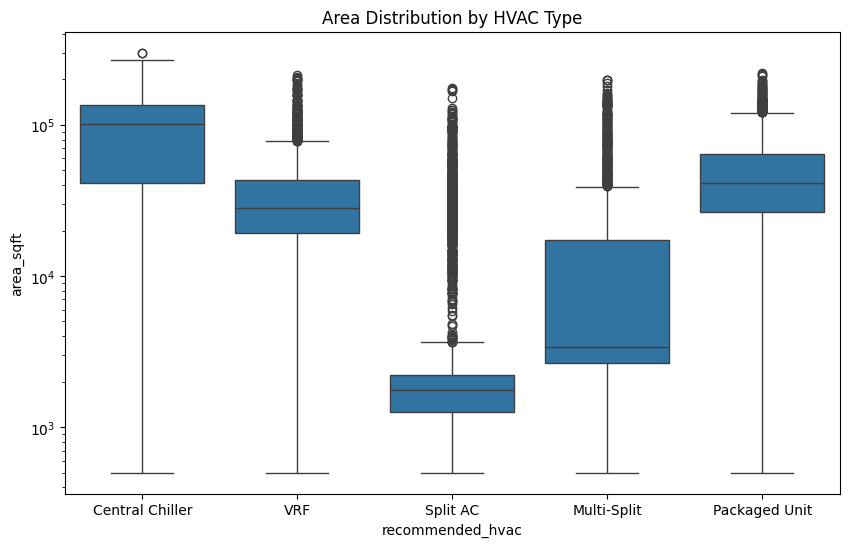

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=model_df,
    x="recommended_hvac",
    y="area_sqft"
)

plt.yscale("log")

plt.title("Area Distribution by HVAC Type")

plt.show()

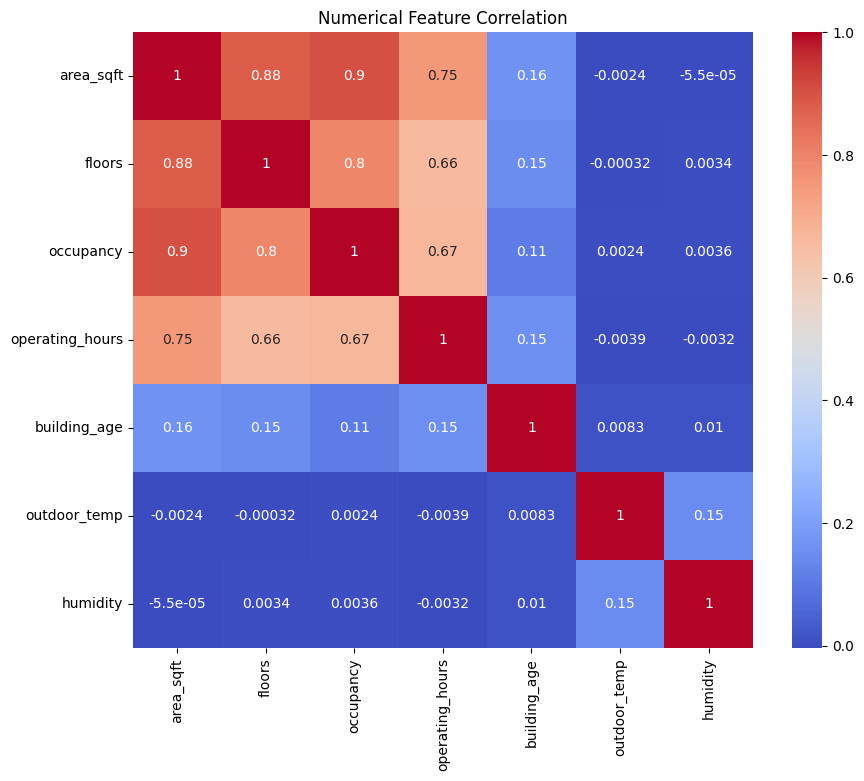

In [ ]:
plt.figure(figsize=(10,8))

sns.heatmap(
    model_df[numerical_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Numerical Feature Correlation")

plt.show()